## Overview
In this exercise you will integrate the trajectory of a two-body system under Newtonian gravity
plus the 2.5PN radiation reaction acceleration. You will then verify that the orbital decay follows the Peters equations, and finally compute the gravitational waveform using the quadrupole
formula. Throughout, keep track of both bodies separately.

In [62]:
import numpy as np
import methods as m 
import integrate as integ
import matplotlib.pyplot as plt

Using internal units G=M=c=1

In [63]:
G = 1.0
c = 1.0

In [64]:
def compute_accelerations (r1, r2, v1, v2, M, G=1.0, c=1.0):

# i nomi non son bellissimi, al massimo li accorcio
    m1 = M[0]
    m2 = M[1]
    r12_vec = r1 - r2
    r12 = np.linalg.norm(r12_vec)
    n12 = r12_vec / r12
    v12_vec = v1 - v2
    v12_squared = np.dot(v12_vec, v12_vec)
    nv12 = np.dot(n12, v12_vec)

    # accelerazione di 1
    # calcolo dei coefficienti

    A1 = (208*G**3*m1*m2**2 / (15*r12**4)
         - 24*G**3*m1**2*m2 / (5*r12**4) 
         + 12*G**2*m1*m2*v12_squared / (5*r12**3)) 
    
    B1 = (8*G**3*m1**2*m2 / (5*r12**4) 
         -32*G**3*m1*m2**2 / (5*r12**4)
         -4*G**2*m1*m2*v12_squared / (5*r12**3))
    
    a1 = -G*m2 / r12**2 * n12 + (1/c**5)*(A1*nv12*n12 + B1*v12_vec)

    # accelerazione di 2
    A2 = (208*G**3*m2*m1**2 / (15*r12**4)
         -  24*G**3*m2**2*m1 / ( 5*r12**4)
         +  12*G**2*m2*m1*v12_squared / (5*r12**3))

    B2 = (  8*G**3*m2**2*m1  / (5*r12**4)
          - 32*G**3*m2*m1**2 / (5*r12**4)
          -  4*G**2*m2*m1*v12_squared / (5*r12**3))
    
    a2 = +G*m1 / r12**2 * n12 + (1/c**5)*(-A2*nv12*n12 - B2*v12_vec)

    return a1, a2



In [65]:
def derivatives (t, y, M):
    r1, r2 = y[0:3], y[3:6]
    v1, v2 = y[6:9], y[9:12]
    a1, a2 = compute_accelerations(r1, r2, v1, v2, M)
    return np.concatenate([v1, v2, a1, a2])

In [66]:
def T_merger_circular (a0, M, G=1.0, c=1.0):
    m1 = M[0]
    m2 = M[1]
    Beta = (64/5)*G**3*m1*m2*(m1+m2) / c**5
    return a0**4 / (4*Beta)


In [67]:
def init_cond_peri (M, a0, e0, G=1.0):
    m1 = M[0]
    m2 = M[1]

    r_peri = a0*(1-e0)

    r1 = -r_peri * m2 / (m1 + m2) * np.array([1, 0, 0])
    r2 =  r_peri * m1 / (m1 + m2) * np.array([1, 0, 0])

    v_peri = np.sqrt(G * (m1+m2) / a0 * (1 + e0) / (1 - e0))

    v1 =  m2 / (m1 + m2) * v_peri * np.array([0, 1, 0])
    v2 = -m1 / (m1 + m2) * v_peri * np.array([0, 1, 0])

    return np.concatenate([r1, r2, v1, v2])



In [77]:
def compute_a(y, M, G=1.0, c=1.0):
    y = np.asarray(y)
    r1, r2 = y[:, 0:3], y[:, 3:6]
    v1, v2 = y[:, 6:9], y[:, 9:12]
    m1 = M[0]
    m2 = M[1]
    r12_vec = r1 - r2
    r12 = np.linalg.norm(r12_vec, axis=1)
    v12_vec = v1 - v2
    v12_sq = np.sum(v12_vec**2, axis=1)

    eps = (v12_sq / 2.0) - (G*(m1+m2) / r12)
    a = -G*(m1+m2) / (2*eps)
    return a



In [79]:
def compute_eccentricity(y, M, a, G=1.0, c=1.0):
    y = np.asarray(y)
    r1, r2 = y[:, 0:3], y[:, 3:6]
    v1, v2 = y[:, 6:9], y[:, 9:12]
    m1 = M[0]
    m2 = M[1]
    r12_vec = r1 - r2
    v12_vec = v1 - v2
    
    
    h = np.cross(r12_vec, v12_vec)
    h_sq = np.sum(h**2, axis=1)

    e = np.sqrt(1- h_sq / (G*(m1+m2)*a))

    return e

In [ ]:
#sta funzione fa schifo, la dovrò rifare meglio
def plot (x, y, title = None, xlabel = None, ylabel = None, grid = True, legend = True, xlim=None, ylim=None):
    fig, ax = plt.subplots(figsize=(10,8))
    ax.plot(x, y)
    if title is not None:
        ax.set_title(title)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)
    if grid:
        ax.grid()
    if legend:
        ax.legend()
    plt.show()

In [71]:
m1 = 0.5
m2 = 0.5
M = np.array([m1, m2])

a0 = 12.0 #nel caso lo cambio
e0 = 0.1 #quasi circular orbit

t_start = 0.0
t_end = T_merger_circular(a0, M, G, c) *0.97 #moltiplico per 0.97 perchè l'approssimazione altrimenti mi fa arrivare un po' lungo e becco il merger
t_range = (t_start, t_end)

IC = init_cond_peri(M, a0, e0, G)

h = 0.1 #per ora lo metto a caso, poi ci dedico attenzione



In [72]:
t, y = integ.integrate(derivatives, t_range, IC, h, args=M, method=m.RK4, extra_par=None)

print (y[0])

[-5.4        -0.         -0.          5.4         0.          0.
  0.          0.15957118  0.         -0.         -0.15957118 -0.        ]


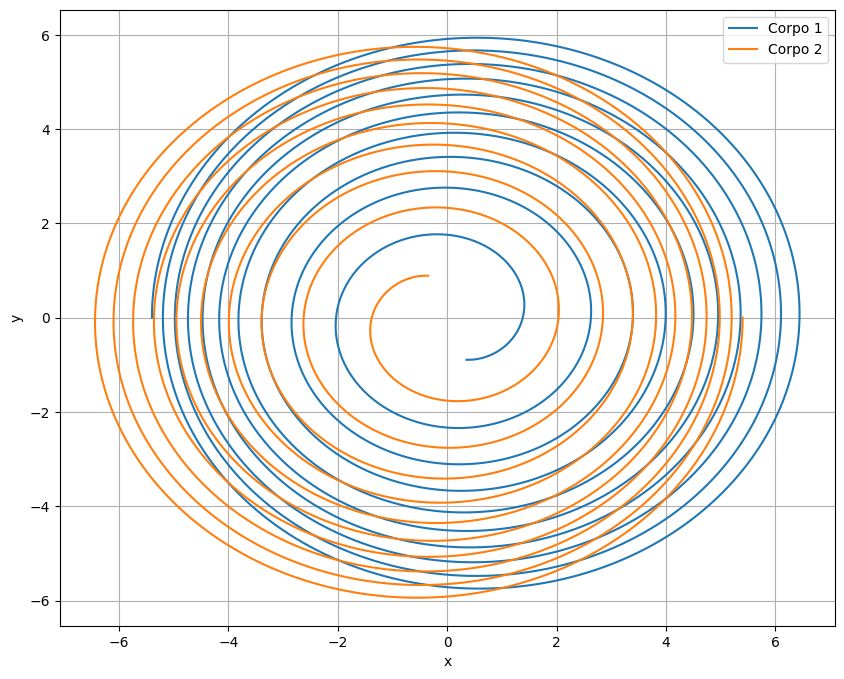

15716


In [73]:
r1_x = y[:, 0]
r1_y = y[:, 1]

r2_x = y[:, 3]
r2_y = y[:, 4]

fig, ax = plt.subplots(figsize=(10,8))

ax.set_xlabel('x')
ax.set_ylabel('y')

ax.plot(r1_x, r1_y, label='Corpo 1')
ax.plot(r2_x, r2_y, label='Corpo 2')

# ax.set_xlim(-1, 1)
# ax.set_ylim(-1, 1)

ax.legend()
ax.grid()
plt.show()

print (len(t))

sto attengo a che t merger mettere

In [74]:
# from matplotlib.animation import FuncAnimation



# fig, ax = plt.subplots(figsize=(8, 8))
# ax.set_xlim(np.min(y[:, [0, 3]]) * 1.1, np.max(y[:, [0, 3]]) * 1.1)
# ax.set_ylim(np.min(y[:, [1, 4]]) * 1.1, np.max(y[:, [1, 4]]) * 1.1)
# ax.set_aspect('equal')
# ax.grid(True)

# line1, = ax.plot([], [], 'b-', alpha=0.3) # Scia corpo 1
# point1, = ax.plot([], [], 'bo', label='Corpo 1') # Punto corpo 1

# line2, = ax.plot([], [], 'r-', alpha=0.3) # Scia corpo 2
# point2, = ax.plot([], [], 'ro', label='Corpo 2') # Punto corpo 2

# ax.legend()

# def init():
#     line1.set_data([], [])
#     point1.set_data([], [])
#     line2.set_data([], [])
#     point2.set_data([], [])
#     return line1, point1, line2, point2

# def update(i):
#     # Aggiorna scia (dal frame 0 al frame attuale i)
#     line1.set_data(r1_x[:i], r1_y[:i])
#     line2.set_data(r2_x[:i], r2_y[:i])
    
#     # Aggiorna posizione attuale (solo il frame i)
#     # Nota: set_data vuole sequenze, quindi usiamo [r1_x[i]]
#     point1.set_data([r1_x[i]], [r1_y[i]])
#     point2.set_data([r2_x[i]], [r2_y[i]])
    
#     return line1, point1, line2, point2

# # 5. Creazione animazione
# # frames: quanti frame totali (pari alla lunghezza del vettore tempi t)
# # interval: millisecondi tra i frame
# ani = FuncAnimation(fig, update, frames=range(0, len(t), 50), init_func=init, blit=True, interval=50)

# ani.save('orbita_animata.gif', writer='pillow', fps=20)
# plt.close(fig)



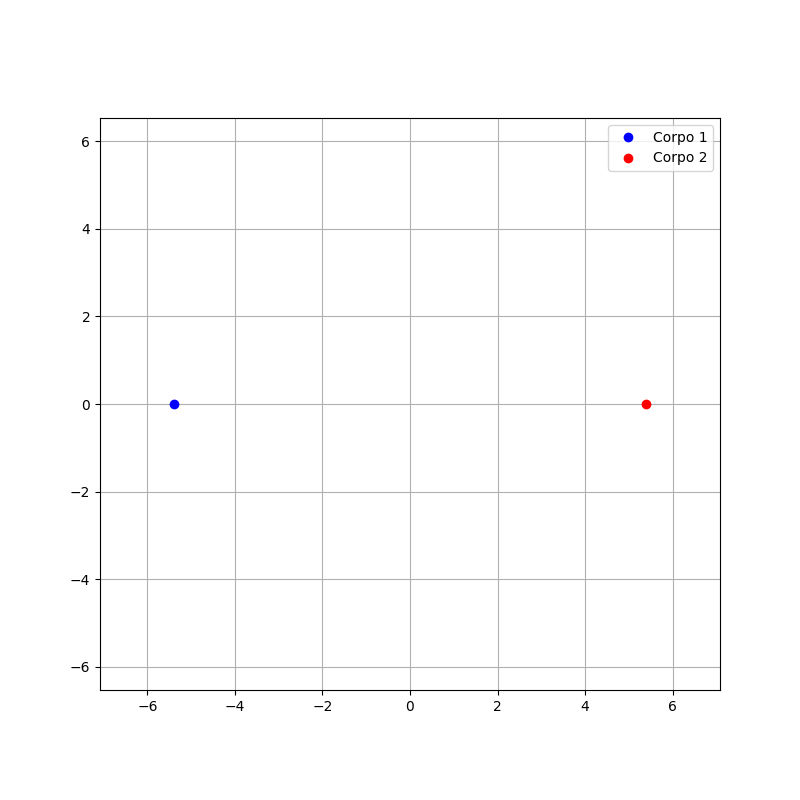

In [75]:
from IPython.display import Image
Image(open('orbita_animata.gif','rb').read())

/tmp/ipykernel_15301/167789851.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


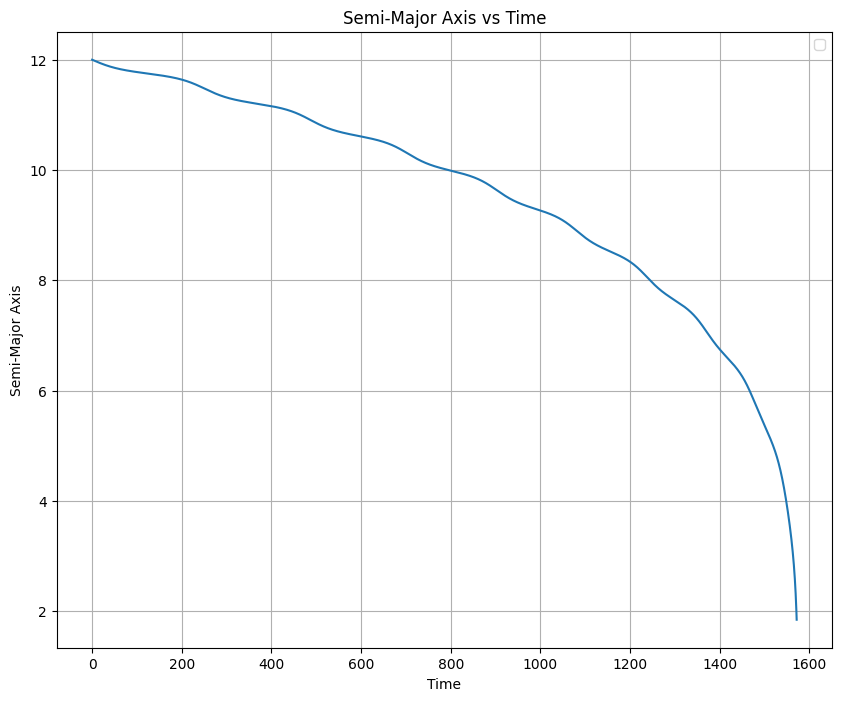

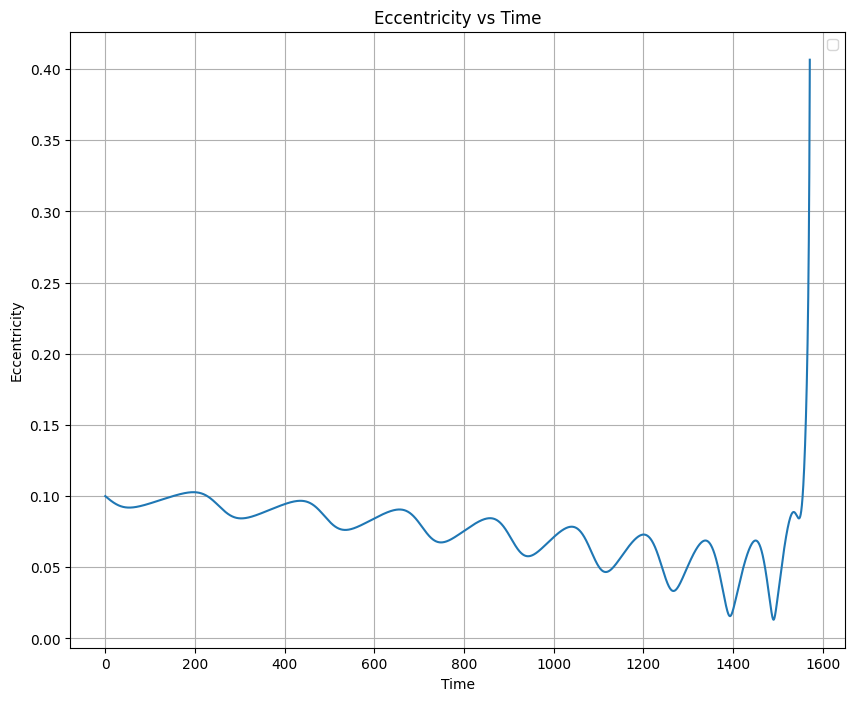

In [81]:
a = compute_a(y, M, G, c)
e = compute_eccentricity(y, M, a, G, c)

plot(t, a, title='Semi-Major Axis vs Time', xlabel='Time', ylabel='Semi-Major Axis')
plot(t, e, title='Eccentricity vs Time', xlabel='Time', ylabel='Eccentricity')

## Part 2: Comparison with the Peters Equations